In [1]:
from config.load_config import load_config
from training.optimizer_scheduler import define_optimizer_and_scheduler
from models.action_model import ActionRecognitionModelWithoutSelector,ActionRecognitionModelWithMotionSelector
from data.video_dataset import create_datasets
from data.video_dataloader import load_dataloader
from data.transform import VideoTrainTransform,VideoValTransform
from training.train_and_evaluate import train_and_evaluate
from utils.helper_functions import save_experiment,set_seed
from pathlib import Path
import torch
import torch.nn as nn
import torchmetrics
from tqdm import tqdm
import optuna

c:\Users\javie\Documents\William V\paper\venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
root=Path.cwd()

config_path=Path("configs/base.yaml")

cfg = load_config(config_path)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

data_cfg=cfg.data
model_cfg=cfg.model
train_cfg=cfg.train

root_path=root/cfg.data.dataset.root

train_path=root_path/"train"
val_path=root_path/"val"

In [3]:
def objective(trial,device):

    num_heads=trial.suggest_categorical(f"num_heads",[2,4,6])

    head_dim = trial.suggest_categorical("head_dim", [32, 64])

    dim_encoder=head_dim*num_heads
    trial.set_user_attr("dim_encoder", dim_encoder)

    hidden_units_mlp=[trial.suggest_categorical(f"hidden_unit_{i}",[128,256,512,1024]) for i in range(2)]


    lr = trial.suggest_float("lr", 1e-5, 5e-4, log=True)
    weight_decay = trial.suggest_float("weight_decay", 1e-6, 1e-3, log=True)


    train_dataset,val_dataset=create_datasets(train_path=train_path,
                                                    val_path=val_path,
                                                    num_frames=data_cfg.dataset.selector.selected_frames,
                                                    strategy=data_cfg.dataset.selector.strategy, ##IMPORTANTE
                                                    train_transform=VideoTrainTransform(),
                                                    val_transform=VideoValTransform())  


    set_seed(seed=3)

    train_dataloader=load_dataloader(train_dataset=train_dataset,
                    val_dataset=val_dataset,
                    batch_size=data_cfg.dataloader.batch_size,
                    is_train_loader=True,
                    num_workers=data_cfg.dataloader.num_workers,
                    seed=3)

    val_dataloader=load_dataloader(train_dataset=train_dataset,
                    val_dataset=val_dataset,
                    batch_size=data_cfg.dataloader.batch_size,
                    is_train_loader=False,
                    num_workers=data_cfg.dataloader.num_workers,
                    seed=3)

    model=None

    if data_cfg.dataset.selector.strategy == "motion-distribution":
        if data_cfg.dataset.selector.selected_frames == None:
            raise Exception("Verificar las variables candidate_frames y selected_frames")
        model= ActionRecognitionModelWithMotionSelector(num_classes=train_cfg.num_classes,
                                                selected_frames=data_cfg.dataset.selector.selected_frames,
                                                dim_encoder=dim_encoder, #dim_encoder
                                                num_heads=num_heads, #num_heads
                                                num_layers=model_cfg.transformer_encoder.num_layers, 
                                                mlp_size=model_cfg.transformer_encoder.mlp_size, 
                                                dropout=model_cfg.dropout,
                                                hidden_units_mlp=hidden_units_mlp) #
    else:
        model = ActionRecognitionModelWithoutSelector(num_classes=train_cfg.num_classes,
                                                    num_frames=data_cfg.dataset.selector.selected_frames,
                                                    dim_encoder=dim_encoder,
                                                    num_heads=num_heads,
                                                    num_layers=model_cfg.transformer_encoder.num_layers,
                                                    mlp_size=model_cfg.transformer_encoder.mlp_size,
                                                    dropout=model_cfg.dropout,
                                                    hidden_units_mlp=hidden_units_mlp)


    optimizer,scheduler=define_optimizer_and_scheduler(model=model,
                                learning_rate=lr,
                                weight_decay=weight_decay,
                                scheduler=train_cfg.scheduler)

    loss_fcn=nn.CrossEntropyLoss()

    _=train_and_evaluate(model=model,
                    train_dataloader=train_dataloader,
                    val_dataloader=val_dataloader,
                    loss_fcn=loss_fcn,
                    optimizer=optimizer,
                    scheduler=scheduler,
                    n_epochs=train_cfg.epochs,
                    warmup_epochs=train_cfg.warmup_epochs,
                    save_path=None,
                    device=device)
    
    model.eval()

    accuracy_metric=torchmetrics.Accuracy(task="multiclass",num_classes=train_cfg.num_classes).to(device)
    precision_metric=torchmetrics.Precision(task="multiclass",num_classes=train_cfg.num_classes,average="macro").to(device)
    recall_metric=torchmetrics.Recall(task="multiclass",num_classes=train_cfg.num_classes,average="macro").to(device)
    f1_metric=torchmetrics.F1Score(task="multiclass",num_classes=train_cfg.num_classes,average="macro").to(device)

    accuracy_metric.reset()
    precision_metric.reset()
    recall_metric.reset()
    f1_metric.reset()

    with torch.inference_mode():
        for X,y in tqdm(val_dataloader):
            X,y=X.to(device),y.to(device)
            y_logits=model(X)
            y_pred = torch.argmax(y_logits, dim=1)
            
            accuracy_metric.update(y_pred,y)
            precision_metric.update(y_pred,y)
            recall_metric.update(y_pred,y)
            f1_metric.update(y_pred,y)

    accuracy=accuracy_metric.compute().item()
    precision=precision_metric.compute().item()
    recall=recall_metric.compute().item()
    f1=f1_metric.compute().item()

    trial.set_user_attr("accuracy", accuracy)
    trial.set_user_attr("precision", precision)
    trial.set_user_attr("recall", recall)

    return f1

In [4]:
seed = 3

sampler = optuna.samplers.TPESampler(seed=seed)  # Use TPE sampler (the default sampler in Optuna)

# Create a study object and optimize the objective function
study_apples = optuna.create_study(direction='maximize', sampler=sampler)

n_trials = 10
study_apples.optimize(lambda trial: objective(trial, device), n_trials=n_trials) 

[I 2026-03-17 03:11:09,190] A new study created in memory with name: no-name-86ee2819-7b5f-43e8-addf-fc0f8c936d4f
c:\Users\javie\Documents\William V\paper\venv\lib\site-packages\torch\nn\modules\transformer.py:392: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(
  3%|▎         | 1/30 [01:04<31:01, 64.19s/it]


Epoch 1: Train loss: 1.6023640380586897 | Train acc: 0.2343 | LR: 0.0000

Epoch 1: Val loss: 1.5889 | Val acc: 0.2667


  7%|▋         | 2/30 [02:07<29:43, 63.71s/it]


Epoch 2: Train loss: 1.528587605839684 | Train acc: 0.3457 | LR: 0.0000

Epoch 2: Val loss: 1.5556 | Val acc: 0.2433


 10%|█         | 3/30 [03:10<28:36, 63.57s/it]

...

 97%|█████████▋| 29/30 [30:09<01:02, 62.46s/it]


Epoch 29: Train loss: 0.058439469940605615 | Train acc: 0.9810 | LR: 0.0002

Epoch 29: Val loss: 1.8210 | Val acc: 0.6433


100%|██████████| 30/30 [31:12<00:00, 62.41s/it]



Epoch 30: Train loss: 0.038965827851068405 | Train acc: 0.9848 | LR: 0.0002

Epoch 30: Val loss: 2.1098 | Val acc: 0.5900


100%|██████████| 5/5 [00:10<00:00,  2.16s/it]
[I 2026-03-17 08:24:22,128] Trial 9 finished with value: 0.5622442960739136 and parameters: {'num_heads': 6, 'head_dim': 32, 'hidden_unit_0': 128, 'hidden_unit_1': 256, 'lr': 0.0001716422070487153, 'weight_decay': 2.6206038368953336e-06}. Best is trial 8 with value: 0.7243850827217102.


In [8]:
df = study_apples.trials_dataframe()

df

,number,value,datetime_start,datetime_complete,duration,params_head_dim,params_hidden_unit_0,params_hidden_unit_1,params_lr,params_num_heads,params_weight_decay,user_attrs_accuracy,user_attrs_dim_encoder,user_attrs_precision,user_attrs_recall,state
0,0,0.499458,2026-03-17 03:11:09.190079,2026-03-17 03:42:33.569666,0 days 00:31:24.379587,64,128,1024,0.000030,4,0.000107,0.523333,256,0.529619,0.523333,COMPLETE
1,1,0.549047,2026-03-17 03:42:33.569666,2026-03-17 04:13:48.436477,0 days 00:31:14.866811,64,256,256,0.000046,2,0.000644,0.573333,128,0.608562,0.573333,COMPLETE
2,2,0.514178,2026-03-17 04:13:48.436477,2026-03-17 04:45:18.206107,0 days 00:31:29.769630,32,256,512,0.000031,2,0.000024,0.520000,64,0.550843,0.520000,COMPLETE
3,3,0.611051,2026-03-17 04:45:18.206107,2026-03-17 05:16:34.709130,0 days 00:31:16.503023,64,512,1024,0.000149,2,0.000117,0.633333,128,0.648279,0.633333,COMPLETE
4,4,0.461330,2026-03-17 05:16:34.709130,2026-03-17 05:47:45.995541,0 days 00:31:11.286411,32,1024,1024,0.000064,4,0.000062,0.506667,128,0.666123,0.506667,COMPLETE
5,5,0.638718,2026-03-17 05:47:45.995541,2026-03-17 06:19:09.780849,0 days 00:31:23.785308,32,1024,512,0.000375,6,0.000329,0.650000,192,0.705941,0.650000,COMPLETE
6,6,0.647292,2026-03-17 06:19:09.780849,2026-03-17 06:50:26.653643,0 days 00:31:16.872794,32,128,1024,0.000448,6,0.000357,0.676667,192,0.727906,0.676667,COMPLETE
7,7,0.534413,2026-03-17 06:50:26.653643,2026-03-17 07:21:41.754644,0 days 00:31:15.101001,32,128,256,0.000051,2,0.000001,0.560000,64,0.569421,0.560000,COMPLETE
8,8,0.724385,2026-03-17 07:21:41.754644,2026-03-17 07:52:58.924630,0 days 00:31:17.169986,32,256,512,0.000265,4,0.000003,0.730000,128,0.744397,0.730000,COMPLETE
9,9,0.562244,2026-03-17 07:52:58.924630,2026-03-17 08:24:22.128532,0 days 00:31:23.203902,32,128,256,0.000172,6,0.000003,0.590000,192,0.651967,0.590000,COMPLETE


In [9]:
best_trial = study_apples.best_trial

print("Best trial:")
print(f"  Value (Accuracy): {best_trial.value:.4f}")

print("  Hyperparameters:")
print(best_trial.params)

Best trial:
  Value (Accuracy): 0.7244
  Hyperparameters:
{'num_heads': 4, 'head_dim': 32, 'hidden_unit_0': 256, 'hidden_unit_1': 512, 'lr': 0.0002647424312494168, 'weight_decay': 3.236686472450496e-06}


In [7]:
import matplotlib.pyplot as plt

C:\Users\javie\AppData\Local\Temp\ipykernel_26864\2423580847.py:2: ExperimentalWarning: optuna.visualization.matplotlib._optimization_history.plot_optimization_history is experimental (supported from v2.2.0). The interface can change in the future.
  optuna.visualization.matplotlib.plot_optimization_history(study_apples)


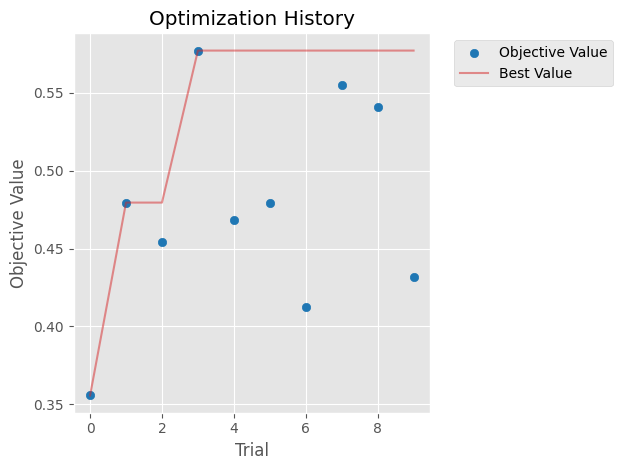

C:\Users\javie\AppData\Local\Temp\ipykernel_26864\2423580847.py:7: ExperimentalWarning: optuna.visualization.matplotlib._param_importances.plot_param_importances is experimental (supported from v2.2.0). The interface can change in the future.
  optuna.visualization.matplotlib.plot_param_importances(study_apples)


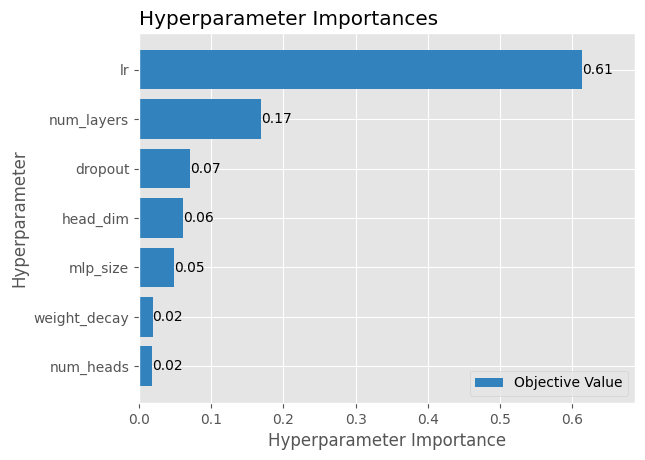

C:\Users\javie\AppData\Local\Temp\ipykernel_26864\2423580847.py:10: ExperimentalWarning: optuna.visualization.matplotlib._parallel_coordinate.plot_parallel_coordinate is experimental (supported from v2.2.0). The interface can change in the future.
  ax = optuna.visualization.matplotlib.plot_parallel_coordinate(


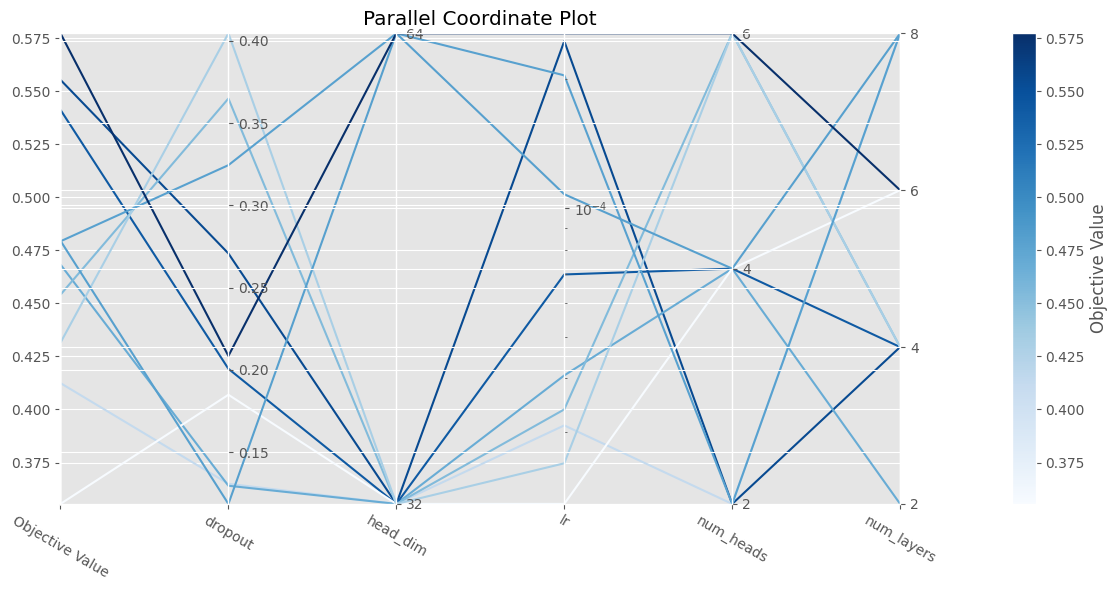

In [16]:
# Plotting the optimization history
optuna.visualization.matplotlib.plot_optimization_history(study_apples)
plt.title('Optimization History')
plt.show()

# Importance of hyperparameters
optuna.visualization.matplotlib.plot_param_importances(study_apples)
plt.show()

ax = optuna.visualization.matplotlib.plot_parallel_coordinate(
    study_apples, params=['num_heads', 'head_dim', 'dropout', 'num_layers', 'lr']
)
fig = ax.figure
fig.set_size_inches(12, 6, forward=True)  # forward=True updates the canvas
fig.tight_layout()